# Segmenting FactoryNet: LeJEPA Embeddings on Real Robot Telemetry

Runs the `self_supervised_physical_ai` pipeline end to end on real data from
[FactoryNet](https://huggingface.co/datasets/factorynet/factorynet), streamed
straight into Delta tables on S3 via `data_warehousing_with_polars`'s
`@incremental` + `@schema`:

1. **Discover schema groups** directly from Hugging Face — FactoryNet's 120 files
   are 10 distinct schemas, not one table (verified, not assumed).
2. **Stream** one group straight from Hugging Face into its own watermarked,
   schema-validated Delta table on S3 — `build_incremental_pipeline` wraps the
   whole `@incremental`/`@schema` composition in one call; no intermediate mirror
   or staging copy.
3. **Read train/test back** from the ingested table via its `source_file` column.
4. **Train** LeJEPA on the train split.
5. **Segment**: embed every held-out test window, cluster with KMeans.
6. **Project** to 2D with t-SNE and **label** a few clusters by majority vote over
   real logged metadata.


In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from dotenv import load_dotenv
from self_supervised_physical_ai import (
    FactoryNetWindowDataset,
    FactoryNetWindowSpec,
    LeJEPAConfig,
    LeJEPAModel,
    SchemaGroup,
    available_metadata_columns,
    build_incremental_pipeline,
    cluster_embeddings,
    embed_dataset,
    group_files_by_schema,
    label_clusters,
    project_tsne,
    select_channel_columns,
    split_files_train_test,
)
from torch.utils.data import DataLoader

load_dotenv()
bucket = os.environ["PHYSICAL_AI_BUCKET"]
# Raises object_store's default ~180s total S3 retry budget for a large write on a
# slow/degrading connection — see project notes on the sink_delta hang this fixed.
STORAGE_OPTIONS = {"timeout": "600s", "connect_timeout": "60s"}
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Shared chart chrome (see the dataviz skill's palette) — used throughout.
INK_PRIMARY = "#0b0b0b"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
bucket, device


ImportError: cannot import name 'build_incremental_pipeline' from 'self_supervised_physical_ai' (/Users/nennia/Projects/data-warehousing-with-polars/packages/self-supervised-physical-ai/src/self_supervised_physical_ai/__init__.py)

## 1. Discover schema groups

Reads every FactoryNet file's schema straight from Hugging Face (parquet footer
only, not the data — one lightweight request per file, no bucket needed yet).
`aursad_*`, `simulations_*`, and the two standalone `factorywave_*` telemetry
files all have 125 columns but are four genuinely *different* schemas — this is
why `build_incremental_pipeline` always ingests one group at a time, each into
its own table.


In [ ]:
schema_groups = group_files_by_schema()

for group_id, group in schema_groups.items():
    print(
        f"{group_id}: {len(group.files):3d} files, {len(group.schema):3d} cols  e.g. {group.files[0]}"
    )


schema_00:  60 files, 139 cols  e.g. voraus_001.parquet
schema_01:  32 files, 125 cols  e.g. aursad_001.parquet
schema_02:  21 files, 125 cols  e.g. simulations_baseline_part_000.parquet
schema_03:   1 files,  57 cols  e.g. cnc_000.parquet
schema_04:   1 files,  13 cols  e.g. factorywave_data_episode_metadata.parquet
schema_05:   1 files,   6 cols  e.g. factorywave_data_flow_metadata.parquet
schema_06:   1 files, 125 cols  e.g. factorywave_data_ur_screwdriver.parquet
schema_07:   1 files,  14 cols  e.g. factorywave_kukadata_episode_metadata.parquet
schema_08:   1 files,   7 cols  e.g. factorywave_kukadata_flow_metadata.parquet
schema_09:   1 files, 125 cols  e.g. factorywave_ur_consolidated.parquet


## 2. Stream a group straight into a Delta table on S3

The largest group (VORAUS-AD, a 6-axis Yu Cobot) — a handful of its 60 files, to
keep this demo's runtime and memory reasonable (the file list is exactly what
`KnownFilesSource` streams; nothing is staged or mirrored first). One call builds
the whole `@incremental` + `@schema` pipeline: watermarked (each file ingested
exactly once, ever), missing documented columns quarantined into their own Delta
table instead of crashing the run, undocumented extras dropped, type mismatches
cast, `episode_id` namespaced by source filename (VORAUS-AD reuses
`"VORAUS_0".."VORAUS_36"` identically across every one of its 60 shards), and a
`source_file` column persisted for exactly this kind of downstream filtering.


In [ ]:
voraus_group_id = max(schema_groups, key=lambda gid: len(schema_groups[gid].files))
voraus_group = schema_groups[voraus_group_id]
demo_files = voraus_group.files[:3]
demo_group = SchemaGroup(schema=voraus_group.schema, files=demo_files)

# VORAUS-specific extras: not generic enough for the default documented-column set
# (METADATA_COLUMNS), but `ctx_action` (the discrete robot motion primitive being
# executed) is exactly what we want to check discovered clusters against later —
# `ctx_anomaly_label`/`ctx_anomaly_category` turn out to be constant within these
# shards' anomaly category, so they won't be useful for that.
extra_metadata = [
    c for c in ("ctx_action", "ctx_setting", "ctx_is_active") if c in voraus_group.schema
]

pipeline = build_incremental_pipeline(
    bucket,
    voraus_group_id,
    demo_group,
    storage_options=STORAGE_OPTIONS,
    extra_columns=extra_metadata,
)
pipeline.target


's3://self-supervised-physical-ai/delta/factorynet_schema_00'

In [ ]:
processed = pipeline.run()
processed


[]

## 3. Confirm the watermark — rerunning does nothing

Every file in `demo_files` is already in the watermark, so this returns `[]`.

In [ ]:
pipeline.run()


[]

In [ ]:
pipeline.maintain()  # OPTIMIZE + VACUUM; also available automatically via compact_every=N
pipeline.status()  # the watermark is itself a Delta table


slot,cursor_json,saved_at
i64,str,"datetime[μs, UTC]"
0,"""[""https://huggingface.co/datas…",2026-07-11 19:19:34.363058 UTC


## 4. Read train/test back from the ingested table

No partitioning needed for this: `source_file` (persisted by `build_incremental_pipeline`)
is exactly the column a file-level train/test split filters on.


In [ ]:
train_files, test_files = split_files_train_test(demo_files, test_size=0.2, seed=0)

full_df = pl.scan_delta(pipeline.target, storage_options=STORAGE_OPTIONS).collect()
train_df = full_df.filter(pl.col("source_file").is_in(train_files))
test_df = full_df.filter(pl.col("source_file").is_in(test_files))

print(
    f"train: {train_df.height} rows, {train_df['episode_id'].n_unique()} episodes ({train_files})"
)
print(f"test:  {test_df.height} rows, {test_df['episode_id'].n_unique()} episodes ({test_files})")
assert set(train_df["episode_id"].unique()) & set(test_df["episode_id"].unique()) == set()


train: 400000 rows, 74 episodes (['voraus_003.parquet', 'voraus_002.parquet'])
test:  200000 rows, 37 episodes (['voraus_001.parquet'])


## 5. Explore the ingested telemetry

A look at what actually landed in the table before windowing/training — episode
duration, what the S-E-F-C channels look like for one real episode, and how
`ctx_action` (used to label clusters later) is distributed.


In [ ]:
print(
    f"{full_df.height} rows, {full_df['episode_id'].n_unique()} episodes, {len(full_df.columns)} columns"
)
full_df.select("setpoint_pos_0", "feedback_pos_0", "effort_current_iq_0", "time_s").describe()


600000 rows, 111 episodes, 112 columns


statistic,setpoint_pos_0,feedback_pos_0,effort_current_iq_0,time_s
str,f64,f64,f64,f64
"""count""",600000.0,600000.0,600000.0,600000.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",0.579895,0.579887,-0.057678,5.556819
"""std""",0.627853,0.629291,1.049268,3.21842
"""min""",-0.341433,-0.349643,-3.834892,0.0
"""25%""",-0.322776,-0.327347,-0.524124,2.77031
"""50%""",1.017107,1.017625,-0.218089,5.543256
"""75%""",1.086007,1.086007,0.446182,8.339951
"""max""",1.086007,1.094228,4.347685,11.58617


### Episode duration

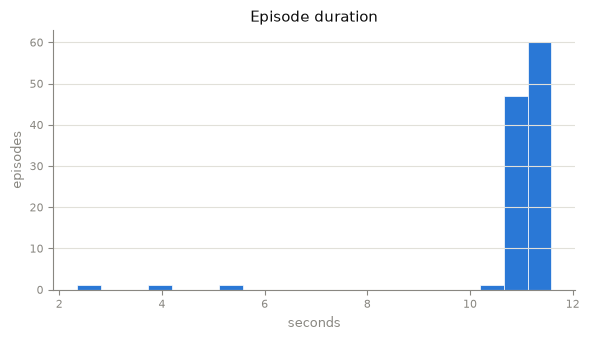

In [ ]:
durations = full_df.group_by("episode_id").agg(pl.col("time_s").max().alias("duration_s"))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(durations["duration_s"], bins=20, color="#2a78d6", edgecolor="white", linewidth=0.5)
ax.set_title("Episode duration", color=INK_PRIMARY, fontsize=11)
ax.set_xlabel("seconds", color=INK_MUTED, fontsize=9)
ax.set_ylabel("episodes", color=INK_MUTED, fontsize=9)
ax.grid(True, color=GRIDLINE, linewidth=0.8, axis="y")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(INK_MUTED)
ax.tick_params(colors=INK_MUTED, labelsize=8)
fig.tight_layout()
plt.show()


### Setpoint vs. feedback for one episode

The commanded trajectory (`setpoint_pos_0`) against what joint 0 actually did
(`feedback_pos_0`) — the gap between the two is exactly the kind of thing a
"physical AI" embedding should end up sensitive to.


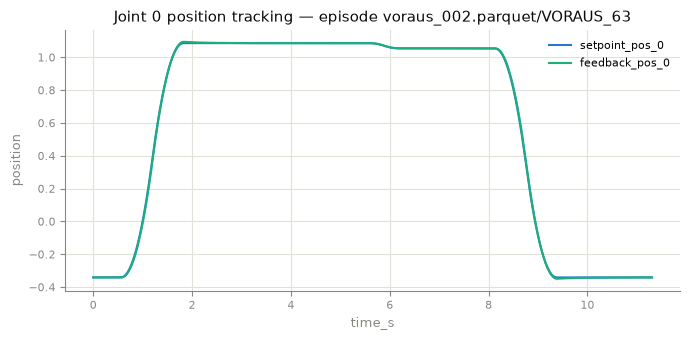

In [ ]:
example_episode = train_df["episode_id"][0]
episode_df = train_df.filter(pl.col("episode_id") == example_episode).sort("time_s")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(
    episode_df["time_s"],
    episode_df["setpoint_pos_0"],
    color="#2a78d6",
    linewidth=1.5,
    label="setpoint_pos_0",
)
ax.plot(
    episode_df["time_s"],
    episode_df["feedback_pos_0"],
    color="#1baf7a",
    linewidth=1.5,
    label="feedback_pos_0",
)
ax.set_title(
    f"Joint 0 position tracking — episode {example_episode}", color=INK_PRIMARY, fontsize=11
)
ax.set_xlabel("time_s", color=INK_MUTED, fontsize=9)
ax.set_ylabel("position", color=INK_MUTED, fontsize=9)
ax.grid(True, color=GRIDLINE, linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(INK_MUTED)
ax.tick_params(colors=INK_MUTED, labelsize=8)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


### `ctx_action` distribution

The discrete motion primitive `label_clusters` will check discovered clusters against later.

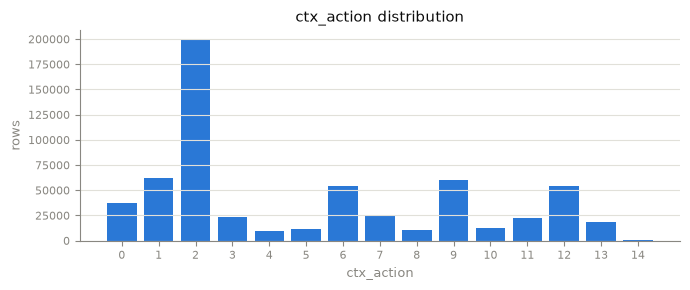

In [ ]:
action_counts = full_df["ctx_action"].value_counts().sort("ctx_action")

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(action_counts["ctx_action"].cast(pl.String), action_counts["count"], color="#2a78d6")
ax.set_title("ctx_action distribution", color=INK_PRIMARY, fontsize=11)
ax.set_xlabel("ctx_action", color=INK_MUTED, fontsize=9)
ax.set_ylabel("rows", color=INK_MUTED, fontsize=9)
ax.grid(True, color=GRIDLINE, linewidth=0.8, axis="y")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(INK_MUTED)
ax.tick_params(colors=INK_MUTED, labelsize=8)
fig.tight_layout()
plt.show()


## 6. Window into per-episode snippets

In [ ]:
channel_columns = select_channel_columns(voraus_group.schema)
metadata_columns = available_metadata_columns(voraus_group.schema)

window_len, patch_len = 128, 16
spec = FactoryNetWindowSpec(
    window_len=window_len,
    stride=64,
    channel_columns=tuple(channel_columns),
    metadata_columns=tuple(
        c for c in metadata_columns + extra_metadata if c not in ("episode_id", "time_s")
    ),
)

train_dataset = FactoryNetWindowDataset(train_df, spec)
test_dataset = FactoryNetWindowDataset(test_df, spec)
len(train_dataset), len(test_dataset)


(6126, 3064)

## 7. Train LeJEPA on the train split

In [ ]:
cfg = LeJEPAConfig(
    n_channels=len(channel_columns),
    window_len=window_len,
    patch_len=patch_len,
    d_model=64,
    n_heads=4,
    n_layers=3,
    predictor_d_model=32,
    predictor_n_heads=4,
    predictor_n_layers=2,
    batch_size=32,
    lr=3e-4,
    epochs=50,
)

loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
model = LeJEPAModel(cfg).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

history = {"total": [], "pred": [], "sigreg": []}
for epoch in range(cfg.epochs):
    model.train()
    running = {"total": 0.0, "pred": 0.0, "sigreg": 0.0}
    n_batches = 0
    for batch in loader:
        x = batch["x"].to(device)
        sr = batch["sample_rate_hz"].to(device)

        out = model(x, sr)
        opt.zero_grad()
        out.loss.backward()
        opt.step()

        running["total"] += out.loss.item()
        running["pred"] += out.pred_loss.item()
        running["sigreg"] += out.sigreg_loss.item()
        n_batches += 1

    for key in history:
        history[key].append(running[key] / n_batches)
    print(
        f"epoch {epoch}: total={history['total'][-1]:.4f} "
        f"pred={history['pred'][-1]:.4f} sigreg={history['sigreg'][-1]:.4f}"
    )


epoch 0: total=0.2549 pred=0.1284 sigreg=0.1265


epoch 1: total=0.1313 pred=0.0442 sigreg=0.0871


epoch 2: total=0.1204 pred=0.0341 sigreg=0.0863


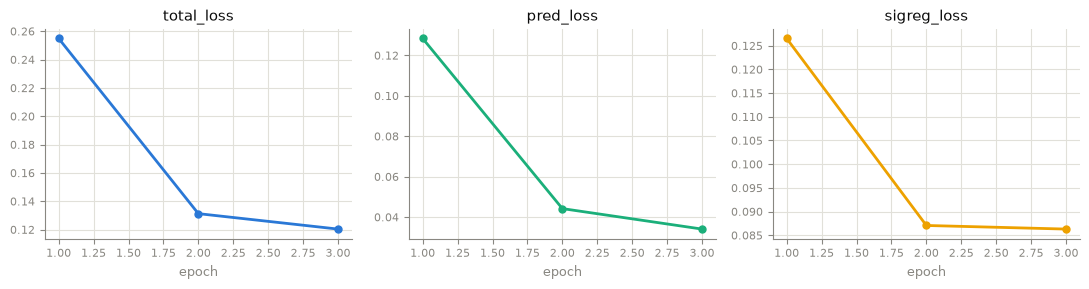

In [ ]:
SERIES = {"total": "#2a78d6", "pred": "#1baf7a", "sigreg": "#eda100"}

fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharex=True)
epochs = range(1, cfg.epochs + 1)
for ax, key in zip(axes, ["total", "pred", "sigreg"]):
    ax.plot(epochs, history[key], color=SERIES[key], linewidth=2, marker="o", markersize=5)
    ax.set_title(f"{key}_loss", color=INK_PRIMARY, fontsize=11)
    ax.set_xlabel("epoch", color=INK_MUTED, fontsize=9)
    ax.grid(True, color=GRIDLINE, linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(INK_MUTED)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
fig.tight_layout()
plt.show()


## 8. Segment the *held-out* test split: embed, then cluster with KMeans

Embedding episodes the encoder never trained on — not the primary evaluation, but
a first pass at "does the embedding space carve unseen telemetry into anything
coherent?".


In [ ]:
embeddings, metadata = embed_dataset(
    model,
    test_dataset,
    metadata_columns=spec.metadata_columns,
    batch_size=128,
    device=device,
)

N_CLUSTERS = 6
cluster_ids = cluster_embeddings(embeddings, n_clusters=N_CLUSTERS, random_state=0)
embeddings.shape, np.bincount(cluster_ids)


((3064, 64), array([419, 592, 697, 500, 379, 477]))

## 9. Project to 2D with t-SNE and label a few clusters

Labels come from a majority vote over `ctx_action` — the real logged motion primitive, not an invented category.

In [ ]:
coords_2d = project_tsne(embeddings, random_state=0)
cluster_labels = label_clusters(cluster_ids, metadata, label_column="ctx_action")
for cluster_id, label in sorted(cluster_labels.items()):
    print(f"cluster {cluster_id}: action {label}")


cluster 0: action 11 (28%)
cluster 1: action 9 (42%)
cluster 2: action 2 (92%)
cluster 3: action 6 (43%)
cluster 4: action 2 (78%)
cluster 5: action 1 (47%)


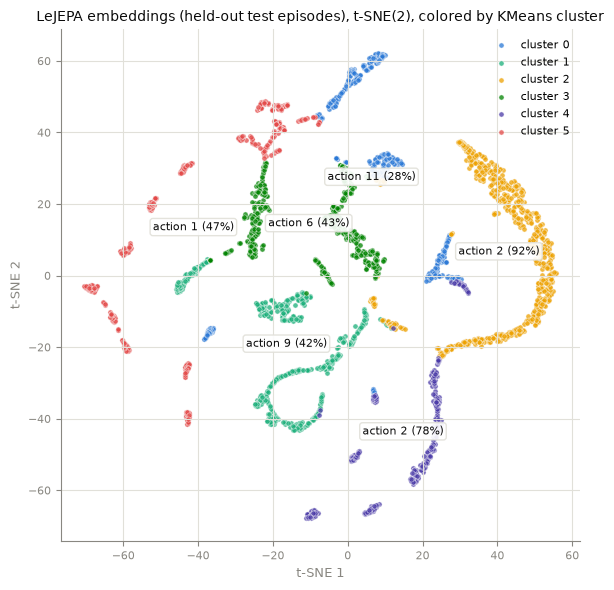

In [ ]:
CLUSTER_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948"]  # fixed order

fig, ax = plt.subplots(figsize=(6, 6))
centroids = {}
for cluster_id in sorted(cluster_labels):
    mask = cluster_ids == cluster_id
    ax.scatter(
        coords_2d[mask, 0],
        coords_2d[mask, 1],
        s=14,
        linewidths=0.4,
        edgecolors="white",
        color=CLUSTER_COLORS[cluster_id % len(CLUSTER_COLORS)],
        alpha=0.75,
        label=f"cluster {cluster_id}",
    )
    centroids[cluster_id] = coords_2d[mask].mean(axis=0)

for cluster_id, (cx, cy) in centroids.items():
    ax.annotate(
        f"action {cluster_labels[cluster_id]}",
        (cx, cy),
        color=INK_PRIMARY,
        fontsize=8,
        ha="center",
        bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": GRIDLINE, "alpha": 0.9},
    )

ax.set_title(
    "LeJEPA embeddings (held-out test episodes), t-SNE(2), colored by KMeans cluster",
    color=INK_PRIMARY,
    fontsize=10,
)
ax.set_xlabel("t-SNE 1", color=INK_MUTED, fontsize=9)
ax.set_ylabel("t-SNE 2", color=INK_MUTED, fontsize=9)
ax.grid(True, color=GRIDLINE, linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(INK_MUTED)
ax.tick_params(colors=INK_MUTED, labelsize=8)
ax.legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()


## Next steps

- Add more of the VORAUS group's 60 files and rebuild the pipeline
  (`build_incremental_pipeline(bucket, voraus_group_id, SchemaGroup(voraus_group.schema,
  files=more_files), storage_options=STORAGE_OPTIONS)`) — same target, so `.run()`
  only ever ingests files not already in the watermark.
- To mirror **every** schema group in one call:
  ```python
  from self_supervised_physical_ai import stream_factorynet_to_bucket
  stream_factorynet_to_bucket(bucket, storage_options=STORAGE_OPTIONS)  # ~13.7 GB — run intentionally
  ```
  Each group lands in its own table (`s3://{bucket}/delta/factorynet_{group_id}`);
  none of them can be concatenated with each other (see step 1).
- `ctx_anomaly_label`/`ctx_anomaly_category` are constant within these shards (same
  anomaly category) — pull in files from across the full 60-file VORAUS group for a
  genuine anomaly-detection framing, and re-run `label_clusters(...,
  label_column="ctx_anomaly_label")`.
- `storage_options` is threaded through every Delta touchpoint `@incremental` makes
  (watermark, quarantine, `compact_every`, every `scd_type`, `compute_context`
  remote writes) — not just the sink.
- Same LeJEPA caveats as before still apply: shared batch mask, no stop-gradient by
  default, patch-level (not pooled) SIGReg — see `lejepa.py`.
